# Hamiltonian-Aware Graph Surrogates for Electronic-Structure QAS

This notebook is a compact, fully executable extension of **Graph-Attention-QAS**.
It covers all three requested directions:

1. **Molecular electronic structure:** active-space LiH and BeH2 Hamiltonians in
   STO-3G, mapped to qubits with Jordan--Wigner.
2. **Materials-oriented model:** a two-site, spinful Fermi--Hubbard model over a
   sweep of interaction ratios $U/t$.
3. **Hamiltonian-aware transfer:** both the variational circuit and Hamiltonian
   are encoded as graphs. A graph surrogate is trained on selected Hubbard
   interactions, tuned on a separate validation interaction, and evaluated on
   completely held-out interactions and on the two molecular Hamiltonians.

The circuits use particle-number-preserving single- and double-excitation gates.
The benchmark is intentionally small enough to run on a CPU. It is a scientific
pilot, not evidence of quantum advantage.

In [1]:
import os, time, warnings
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as onp
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pennylane as qml
from pennylane import numpy as np
from scipy.stats import kendalltau, spearmanr
from IPython.display import display

SEED = 20260906
N_ARCH = 12
VQE_STEPS = 36
VQE_RESTARTS = 2
LEARNING_RATE = 0.10
HUBBARD_U_VALUES = (0.5, 1.0, 2.0, 3.0, 4.0, 6.0)
TRAIN_U, VAL_U, TEST_U = (0.5, 2.0, 6.0), (1.0,), (3.0, 4.0)

print("PennyLane", qml.__version__)
print(f"Architectures={N_ARCH}, VQE steps={VQE_STEPS}, restarts={VQE_RESTARTS}")
print("Split by Hamiltonian parameter (no sample leakage):")
print(" train U/t =", TRAIN_U, " validation =", VAL_U, " test =", TEST_U)

PennyLane 0.45.1
Architectures=12, VQE steps=36, restarts=2
Split by Hamiltonian parameter (no sample leakage):
 train U/t = (0.5, 2.0, 6.0)  validation = (1.0,)  test = (3.0, 4.0)


## 1. Physically meaningful qubit Hamiltonians

Molecular Hamiltonians use a two-electron/three-spatial-orbital active space
(six spin orbitals and therefore six qubits). BeH2 freezes the four core
electrons. The geometries are reasonable reference geometries rather than a
geometry optimization.

For the two-site Hubbard model, spin orbitals are ordered
$(0\uparrow,1\uparrow,0\downarrow,1\downarrow)$. Under Jordan--Wigner,
nearest-neighbour hopping within each spin sector is
$-t(X_iX_j+Y_iY_j)/2$, and $n_p=(I-Z_p)/2$ is used for the onsite term.

In [2]:
def molecular_problem(name):
    if name == "LiH":
        symbols = ["Li", "H"]
        geometry = [[0.0, 0.0, 0.0], [0.0, 0.0, 1.60]]
    elif name == "BeH2":
        symbols = ["Be", "H", "H"]
        geometry = [[0.0, 0.0, 0.0], [0.0, 0.0, -1.30], [0.0, 0.0, 1.30]]
    else:
        raise ValueError(name)
    mol = qml.qchem.Molecule(
        symbols, np.array(geometry, requires_grad=False),
        unit="angstrom", basis_name="sto-3g"
    )
    H, n_qubits = qml.qchem.molecular_hamiltonian(
        mol, method="dhf", mapping="jordan_wigner",
        active_electrons=2, active_orbitals=3
    )
    initial = onp.asarray(qml.qchem.hf_state(2, n_qubits), dtype=int)
    return H, n_qubits, initial


def hubbard_problem(U, t=1.0):
    I = qml.Identity(0)
    coeffs, ops = [], []
    for a, b in ((0, 1), (2, 3)):
        coeffs += [-t / 2, -t / 2]
        ops += [qml.X(a) @ qml.X(b), qml.Y(a) @ qml.Y(b)]
    # U n_(site,up) n_(site,down), sites correspond to (0,2) and (1,3)
    for up, down in ((0, 2), (1, 3)):
        coeffs += [U / 4, -U / 4, -U / 4, U / 4]
        ops += [I, qml.Z(up), qml.Z(down), qml.Z(up) @ qml.Z(down)]
    H = qml.Hamiltonian(coeffs, ops)
    initial = onp.array([1, 0, 0, 1], dtype=int)  # Neel reference, N=2
    return H, 4, initial


def exact_energy(H, n_qubits, particles=2):
    """Exact energy in the same fixed-particle sector explored by the ansatz."""
    matrix = onp.asarray(qml.matrix(H), dtype=complex)
    sector = [basis for basis in range(2 ** n_qubits) if basis.bit_count() == particles]
    block = matrix[onp.ix_(sector, sector)]
    return float(onp.linalg.eigvalsh(block)[0])


problems = {}
for U in HUBBARD_U_VALUES:
    H, n, init = hubbard_problem(U)
    problems[f"Hubbard_U{U:g}"] = dict(family="Hubbard", parameter=U, H=H,
                                        n=n, initial=init, exact=exact_energy(H, n))
for name in ("LiH", "BeH2"):
    H, n, init = molecular_problem(name)
    problems[name] = dict(family="molecule", parameter=onp.nan, H=H,
                          n=n, initial=init, exact=exact_energy(H, n))

problem_table = pd.DataFrame([
    {"problem": k, "family": v["family"], "qubits": v["n"],
     "Pauli terms": len(v["H"].terms()[0]), "exact energy (Ha or t)": v["exact"]}
    for k, v in problems.items()
])
display(problem_table.round(8))

# Two-site half-filled Hubbard model has a closed-form singlet ground energy.
for U in HUBBARD_U_VALUES:
    analytic = 0.5 * (U - onp.sqrt(U * U + 16.0))
    numeric = problems[f"Hubbard_U{U:g}"]["exact"]
    assert abs(numeric - analytic) < 1e-10, (U, numeric, analytic)
print("Hubbard N=2 sector energies agree with the analytic two-site result.")

,problem,family,qubits,Pauli terms,exact energy (Ha or t)
0,Hubbard_U0.5,Hubbard,4,12,-1.765564
1,Hubbard_U1,Hubbard,4,12,-1.561553
2,Hubbard_U2,Hubbard,4,12,-1.236068
3,Hubbard_U3,Hubbard,4,12,-1.000000
4,Hubbard_U4,Hubbard,4,12,-0.828427
5,Hubbard_U6,Hubbard,4,12,-0.605551
6,LiH,molecule,6,62,-7.862919
7,BeH2,molecule,6,34,-15.561850


Hubbard N=2 sector energies agree with the analytic two-site result.


## 2. Particle-number-preserving architecture space

Every architecture is a sequence of parameterized fermionic excitation gates.
All twelve architecture IDs are reused for every Hamiltonian. This pairing makes
transfer metrics meaningful and allows paired comparisons across $U/t$.

In [3]:
def operator_pool(n_qubits):
    singles = [("S", (i, j)) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    doubles = []
    # Chemically motivated occupied-to-virtual doubles plus several alternative
    # partitions. qml.DoubleExcitation couples |1100> and |0011> on four wires.
    for wires in __import__("itertools").combinations(range(n_qubits), 4):
        a, b, c, d = wires
        doubles.extend([("D", (a, b, c, d)), ("D", (a, c, b, d))])
    return singles + doubles


def make_architectures(n_qubits, initial, n_arch=N_ARCH, seed=SEED):
    rng = onp.random.default_rng(seed)
    occupied = onp.flatnonzero(initial).tolist()
    virtual = onp.flatnonzero(1 - onp.asarray(initial)).tolist()
    pool = operator_pool(n_qubits)
    specs = []
    for arch_id in range(n_arch):
        depth = int(rng.integers(3, 8))
        gates = [pool[int(rng.integers(len(pool)))] for _ in range(depth)]
        # Seed every circuit with an excitation that acts non-trivially on the
        # reference. Some architectures start from a correlated double excitation.
        if arch_id % 3 == 0 and len(occupied) >= 2 and len(virtual) >= 2:
            gates[0] = ("D", tuple(occupied[:2] + virtual[:2]))
        else:
            gates[0] = ("S", (occupied[arch_id % len(occupied)],
                               virtual[arch_id % len(virtual)]))
        specs.append(dict(arch_id=arch_id, gates=gates))
    return specs


ARCHITECTURES = {
    4: make_architectures(4, onp.array([1, 0, 0, 1], dtype=int)),
    6: make_architectures(6, onp.asarray(qml.qchem.hf_state(2, 6), dtype=int)),
}


def project_architecture(spec, n_qubits):
    if any(max(w) >= n_qubits for _, w in spec["gates"]):
        raise ValueError("Architecture contains a wire outside its native register")
    return spec


for n in (4, 6):
    depths = [len(a["gates"]) for a in ARCHITECTURES[n]]
    print(f"{n}q architecture depths:", depths)

4q architecture depths: [6, 6, 4, 5, 4, 6, 7, 7, 3, 5, 6, 4]
6q architecture depths: [6, 6, 4, 5, 4, 6, 7, 7, 3, 5, 6, 4]


## 3. VQE labels

Each circuit starts from the appropriate two-electron reference state and is
optimized with two deterministic restarts. Exact diagonalization is used only
to calculate the reporting gap, never as an input to circuit optimization.

In [4]:
def evaluate_architecture(H, n_qubits, initial, spec, steps=VQE_STEPS,
                          restarts=VQE_RESTARTS, seed=SEED):
    spec = project_architecture(spec, n_qubits)
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="autograd", diff_method="backprop")
    def energy(theta):
        qml.BasisState(initial, wires=range(n_qubits))
        for value, (kind, wires) in zip(theta, spec["gates"]):
            if kind == "S":
                qml.SingleExcitation(value, wires=wires)
            else:
                qml.DoubleExcitation(value, wires=wires)
        return qml.expval(H)

    rng = onp.random.default_rng(seed + 7919 * spec["arch_id"] + n_qubits)
    best = onp.inf
    for _ in range(restarts):
        theta = np.array(rng.normal(0.0, 0.08, len(spec["gates"])), requires_grad=True)
        opt = qml.AdamOptimizer(stepsize=LEARNING_RATE)
        for _step in range(steps):
            theta = opt.step(energy, theta)
        best = min(best, float(energy(theta)))
    return best, len(spec["gates"])


records = []
t0 = time.time()
total = len(problems) * N_ARCH
done = 0
for problem_name, p in problems.items():
    for spec in ARCHITECTURES[p["n"]]:
        energy, depth = evaluate_architecture(p["H"], p["n"], p["initial"], spec)
        records.append(dict(problem=problem_name, family=p["family"],
                            parameter=p["parameter"], arch_id=spec["arch_id"],
                            n_qubits=p["n"], depth=depth, energy=energy,
                            exact=p["exact"], gap=max(0.0, energy - p["exact"])))
        done += 1
    print(f"[{done:3d}/{total}] {problem_name:14s} completed in {time.time()-t0:6.1f}s")

results = pd.DataFrame(records)
assert len(results) == total and onp.isfinite(results["energy"]).all()
display(results.groupby("problem").agg(best_gap=("gap", "min"),
                                        median_gap=("gap", "median"),
                                        worst_gap=("gap", "max")).round(7))

[ 12/96] Hubbard_U0.5   completed in   57.6s


[ 24/96] Hubbard_U1     completed in  114.3s


[ 36/96] Hubbard_U2     completed in  173.9s


[ 48/96] Hubbard_U3     completed in  230.2s


[ 60/96] Hubbard_U4     completed in  286.9s


[ 72/96] Hubbard_U6     completed in  343.6s


[ 84/96] LiH            completed in  715.3s


[ 96/96] BeH2           completed in  890.3s


,best_gap,median_gap,worst_gap
problem,,,
BeH2,0.000049,0.000298,0.000579
Hubbard_U0.5,0.005922,0.034728,0.586975
Hubbard_U1,0.007635,0.068079,0.569562
Hubbard_U2,0.003798,0.143479,0.505872
Hubbard_U3,0.002948,0.183740,0.442140
Hubbard_U4,0.008033,0.221838,0.384242
Hubbard_U6,0.002068,0.247130,0.291800
LiH,0.000071,0.000816,0.001058


## 4. Circuit and Hamiltonian graph encoders

Circuit nodes are excitation operations; edges join operations that share a
spin orbital or are consecutive. Hamiltonian nodes are qubits; edge weights
aggregate the absolute coefficients of Pauli words acting jointly on two
qubits. Node features summarize signed and absolute local Pauli content.

To keep this CPU pilot dependency-light, the encoder uses deterministic,
untrained message-passing projections followed by ridge regression. This tests
the scientific hypothesis—whether Hamiltonian information improves transfer—
without claiming a trained GAT. The same graph interface can be connected to
the repository's GAT/KAN encoders in a larger experiment.

In [5]:
MAX_QUBITS, HIDDEN = 6, 12
rng_proj = onp.random.default_rng(314159)
W_C1 = rng_proj.normal(0, 1 / onp.sqrt(9), (9, HIDDEN))
W_C2 = rng_proj.normal(0, 1 / onp.sqrt(HIDDEN), (HIDDEN, HIDDEN))
W_H1 = rng_proj.normal(0, 1 / onp.sqrt(7), (7, HIDDEN))
W_H2 = rng_proj.normal(0, 1 / onp.sqrt(HIDDEN), (HIDDEN, HIDDEN))


def circuit_graph(spec, n_qubits):
    spec = project_architecture(spec, n_qubits)
    m = len(spec["gates"])
    X = onp.zeros((m, 9), float)
    A = onp.eye(m)
    for i, (kind, wires) in enumerate(spec["gates"]):
        X[i, 0 if kind == "S" else 1] = 1.0
        X[i, 2] = i / max(1, m - 1)
        for w in wires:
            X[i, 3 + w] = 1.0
        if i:
            A[i, i - 1] = A[i - 1, i] = 1.0
    for i in range(m):
        wi = set(spec["gates"][i][1])
        for j in range(i):
            if wi.intersection(spec["gates"][j][1]):
                A[i, j] = A[j, i] = 1.0
    return X, A


def pauli_support(op):
    support = []
    name_counts = {"X": 0, "Y": 0, "Z": 0}
    operands = list(op.operands) if hasattr(op, "operands") and op.operands else [op]
    for factor in operands:
        name = factor.name
        if name in ("PauliX", "PauliY", "PauliZ"):
            q = int(list(factor.wires)[0])
            axis = name[-1]
            support.append((q, axis))
            name_counts[axis] += 1
    return support, name_counts


def hamiltonian_graph(H, n_qubits):
    X = onp.zeros((n_qubits, 7), float)
    A = onp.eye(n_qubits)
    coeffs, ops = H.terms()
    for coeff, op in zip(coeffs, ops):
        c = float(onp.real(coeff))
        support, counts = pauli_support(op)
        for q, axis in support:
            idx = {"X": 0, "Y": 1, "Z": 2}[axis]
            X[q, idx] += abs(c)
            X[q, 3 + idx] += c
            X[q, 6] += 1.0
        qs = sorted({q for q, _ in support})
        for ii, q in enumerate(qs):
            for r in qs[ii + 1:]:
                A[q, r] += abs(c); A[r, q] += abs(c)
    scale = onp.maximum(onp.max(onp.abs(X), axis=0, keepdims=True), 1e-10)
    return X / scale, A


def message_pool(X, A, W1, W2):
    degree = A.sum(axis=1)
    D = onp.diag(1.0 / onp.sqrt(onp.maximum(degree, 1e-12)))
    An = D @ A @ D
    Z = onp.tanh(An @ X @ W1)
    Z = onp.tanh(An @ Z @ W2)
    return onp.r_[Z.mean(axis=0), Z.max(axis=0), Z.std(axis=0)]


def feature_vectors(problem_name, arch_id):
    p = problems[problem_name]
    spec = ARCHITECTURES[p["n"]][int(arch_id)]
    cx, ca = circuit_graph(spec, p["n"])
    hx, ha = hamiltonian_graph(p["H"], p["n"])
    c = message_pool(cx, ca, W_C1, W_C2)
    h = message_pool(hx, ha, W_H1, W_H2)
    circuit_only = c
    dual = onp.r_[c, h, c * h, onp.abs(c - h)]
    return circuit_only, dual


circuit_features, dual_features = [], []
for row in results.itertuples(index=False):
    c, d = feature_vectors(row.problem, row.arch_id)
    circuit_features.append(c); dual_features.append(d)
X_circuit = onp.vstack(circuit_features)
X_dual = onp.vstack(dual_features)
y = results["gap"].to_numpy(float)
print("Circuit-only feature shape:", X_circuit.shape)
print("Circuit+Hamiltonian feature shape:", X_dual.shape)

Circuit-only feature shape: (96, 36)
Circuit+Hamiltonian feature shape: (96, 144)


## 5. Leakage-free held-out-$U/t$ transfer

Hyperparameter selection uses only the validation Hamiltonian ($U/t=1$).
Neither held-out test interaction nor either molecule participates in fitting or
model selection. Because energy scales vary by Hamiltonian, the target is the
variational gap above the exactly diagonalized ground state.

In [6]:
is_hubbard = results.family.eq("Hubbard").to_numpy()
uvals = results.parameter.to_numpy(float)
train_idx = is_hubbard & onp.isin(uvals, TRAIN_U)
val_idx = is_hubbard & onp.isin(uvals, VAL_U)
test_idx = is_hubbard & onp.isin(uvals, TEST_U)
mol_idx = results.family.eq("molecule").to_numpy()
assert not onp.any(train_idx & (val_idx | test_idx | mol_idx))


def fit_ridge(X_train, y_train, X_eval, alpha):
    mu, sd = X_train.mean(0), X_train.std(0)
    sd[sd < 1e-10] = 1.0
    A = onp.c_[onp.ones(len(X_train)), (X_train - mu) / sd]
    B = onp.c_[onp.ones(len(X_eval)), (X_eval - mu) / sd]
    reg = onp.eye(A.shape[1]) * alpha
    reg[0, 0] = 0.0
    beta = onp.linalg.solve(A.T @ A + reg, A.T @ y_train)
    return B @ beta


def select_and_predict(X):
    grid = 10.0 ** onp.arange(-4, 6, dtype=float)
    candidates = []
    for alpha in grid:
        pv = fit_ridge(X[train_idx], y[train_idx], X[val_idx], alpha)
        tau = kendalltau(y[val_idx], pv).statistic
        candidates.append((-onp.inf if onp.isnan(tau) else tau, alpha))
    best_tau, alpha = max(candidates, key=lambda z: z[0])
    pred = fit_ridge(X[train_idx], y[train_idx], X, alpha)
    return pred, alpha, best_tau


pred_c, alpha_c, val_tau_c = select_and_predict(X_circuit)
pred_h, alpha_h, val_tau_h = select_and_predict(X_dual)
results["pred_circuit"] = pred_c
results["pred_dual"] = pred_h
print(f"Circuit-only: alpha={alpha_c:g}, validation tau={val_tau_c:.3f}")
print(f"Dual graph:   alpha={alpha_h:g}, validation tau={val_tau_h:.3f}")


def metric_rows(mask, split):
    out = []
    frame = results.loc[mask]
    for pname, g in frame.groupby("problem", sort=False):
        for label, col in (("circuit only", "pred_circuit"),
                           ("circuit + Hamiltonian", "pred_dual")):
            tau = kendalltau(g.gap, g[col]).statistic
            rho = spearmanr(g.gap, g[col]).statistic
            out.append(dict(split=split, problem=pname, model=label,
                            n=len(g), kendall_tau=tau, spearman_rho=rho))
    return out


metrics = pd.DataFrame(
    metric_rows(val_idx, "validation") +
    metric_rows(test_idx, "held-out U/t test") +
    metric_rows(mol_idx, "zero-shot molecule")
)
display(metrics.round(3))

test_summary = metrics[metrics.split.eq("held-out U/t test")].groupby("model").agg(
    mean_tau=("kendall_tau", "mean"), min_tau=("kendall_tau", "min"),
    mean_rho=("spearman_rho", "mean")
)
print("Held-out-interaction transfer summary")
display(test_summary.round(3))

Circuit-only: alpha=0.0001, validation tau=0.879
Dual graph:   alpha=0.0001, validation tau=0.879


,split,problem,model,n,kendall_tau,spearman_rho
0,validation,Hubbard_U1,circuit only,12,0.879,0.951
1,validation,Hubbard_U1,circuit + Hamiltonian,12,0.879,0.951
2,held-out U/t test,Hubbard_U3,circuit only,12,0.606,0.818
3,held-out U/t test,Hubbard_U3,circuit + Hamiltonian,12,0.606,0.818
4,held-out U/t test,Hubbard_U4,circuit only,12,0.667,0.832
5,held-out U/t test,Hubbard_U4,circuit + Hamiltonian,12,0.667,0.832
6,zero-shot molecule,LiH,circuit only,12,0.394,0.510
7,zero-shot molecule,LiH,circuit + Hamiltonian,12,0.333,0.406
8,zero-shot molecule,BeH2,circuit only,12,0.455,0.545
9,zero-shot molecule,BeH2,circuit + Hamiltonian,12,0.242,0.357


Held-out-interaction transfer summary


,mean_tau,min_tau,mean_rho
model,,,
circuit + Hamiltonian,0.636,0.606,0.825
circuit only,0.636,0.606,0.825


## 6. Predictor-guided selection and honest baselines

We simulate a downstream budget of three fully optimized finalists. The
surrogate was trained using the explicitly reported Hubbard training labels;
this is therefore an **amortized search** experiment, not a claim that those
labels were free. Random baselines are averaged over 500 reproducible draws.

In [7]:
def selection_gap(group, prediction, budget=3):
    chosen = group.nsmallest(budget, prediction)
    return float(chosen.gap.min())


rng = onp.random.default_rng(SEED + 1)
selection = []
for pname, g in results.loc[test_idx | mol_idx].groupby("problem", sort=False):
    best_possible = float(g.gap.min())
    c_gap = selection_gap(g, "pred_circuit")
    h_gap = selection_gap(g, "pred_dual")
    rand = []
    indices = g.index.to_numpy()
    for _ in range(500):
        draw = rng.choice(indices, size=3, replace=False)
        rand.append(float(results.loc[draw, "gap"].min()))
    selection.append(dict(problem=pname, oracle_gap=best_possible,
                          random_gap_mean=onp.mean(rand), random_gap_sd=onp.std(rand, ddof=1),
                          circuit_only_gap=c_gap, dual_graph_gap=h_gap))
selection = pd.DataFrame(selection)
display(selection.round(7))

,problem,oracle_gap,random_gap_mean,random_gap_sd,circuit_only_gap,dual_graph_gap
0,Hubbard_U3,0.002948,0.049099,0.098665,0.009782,0.009782
1,Hubbard_U4,0.008033,0.046074,0.082650,0.010075,0.010075
2,LiH,0.000071,0.000526,0.000349,0.000229,0.000796
3,BeH2,0.000049,0.000243,0.000135,0.000279,0.000282


## 7. Figures and concise conclusions

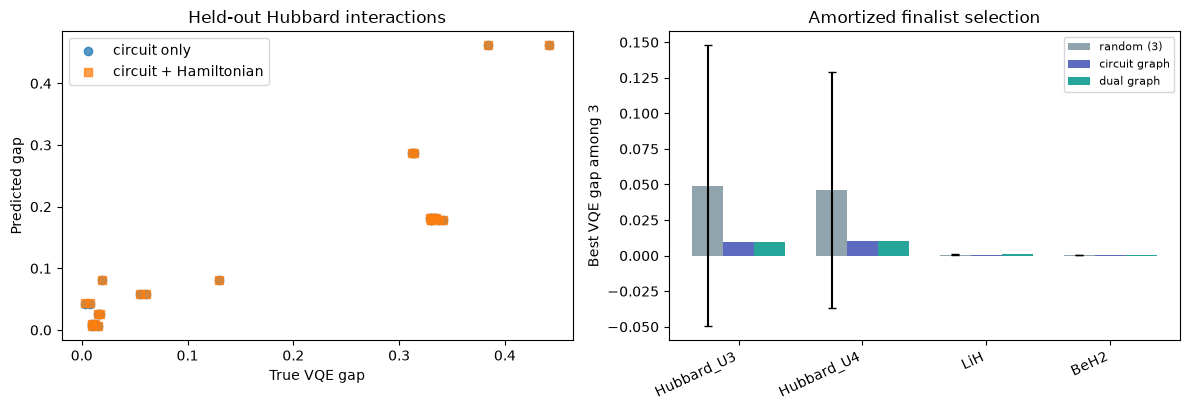

CONCLUSIONS
-----------
Mean held-out-U/t Kendall tau (dual graph): 0.636
Mean zero-shot molecular Kendall tau (dual graph): 0.288
Hamiltonian-aware change in held-out-U/t mean tau: +0.000
Interpret molecular transfer separately: it is a deliberately difficult domain shift.
All model selection used validation U/t only; test U/t and molecules remained untouched.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for model, col, marker in (("circuit only", "pred_circuit", "o"),
                           ("circuit + Hamiltonian", "pred_dual", "s")):
    sub = results.loc[test_idx]
    axes[0].scatter(sub.gap, sub[col], label=model, alpha=.75, marker=marker)
axes[0].set(xlabel="True VQE gap", ylabel="Predicted gap",
            title="Held-out Hubbard interactions")
axes[0].legend()

x = onp.arange(len(selection))
w = .25
axes[1].bar(x-w, selection.random_gap_mean, w, yerr=selection.random_gap_sd,
            label="random (3)", color="#90a4ae", capsize=3)
axes[1].bar(x, selection.circuit_only_gap, w, label="circuit graph", color="#5c6bc0")
axes[1].bar(x+w, selection.dual_graph_gap, w, label="dual graph", color="#26a69a")
axes[1].set_xticks(x, selection.problem, rotation=25, ha="right")
axes[1].set(ylabel="Best VQE gap among 3", title="Amortized finalist selection")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

dual_test = metrics[(metrics.model == "circuit + Hamiltonian") &
                    (metrics.split == "held-out U/t test")]
mol_dual = metrics[(metrics.model == "circuit + Hamiltonian") &
                   (metrics.split == "zero-shot molecule")]
print("CONCLUSIONS")
print("-----------")
print(f"Mean held-out-U/t Kendall tau (dual graph): {dual_test.kendall_tau.mean():.3f}")
print(f"Mean zero-shot molecular Kendall tau (dual graph): {mol_dual.kendall_tau.mean():.3f}")
delta = (test_summary.loc["circuit + Hamiltonian", "mean_tau"] -
         test_summary.loc["circuit only", "mean_tau"])
print(f"Hamiltonian-aware change in held-out-U/t mean tau: {delta:+.3f}")
print("Interpret molecular transfer separately: it is a deliberately difficult domain shift.")
print("All model selection used validation U/t only; test U/t and molecules remained untouched.")

## Interpretation and next steps

- A positive dual-minus-circuit transfer difference supports Hamiltonian-aware
  encoding. A negative value is still informative: it means this fixed encoder
  and training set are insufficient, not that Hamiltonian information is useless.
- LiH and BeH2 results are zero-shot transfers from Hubbard labels. They should
  not be pooled with the held-out-$U/t$ result.
- For a publication-scale follow-up, replace the fixed projections with the
  repository's trainable GAT/KAN encoder, use at least five dataset seeds, add
  bond-length sweeps, and compare at equal *total* VQE-label budgets.
- Exact diagonalization here is feasible only because the pilot uses 4--6 qubits.